 In the last lesson, we created an entangled state. Now, let's use that entanglement to do something that seems impossible: send two pieces of information by physically moving only one qubit.

This protocol is called Superdense Coding.

## Lesson: Superdense Coding 📮

The Mission: Alice wants to send a two-bit classical message to Bob (either 00, 01, 10, or 11). They already share an entangled pair of qubits. Alice will only perform operations on her qubit and then send only her qubit to Bob. By measuring both qubits, Bob can perfectly recover her two-bit message.

Step 1: The Setup - Sharing Entanglement

First, Alice and Bob must share an entangled pair. This is the exact same Bell state circuit you built in Lesson 8. We'll assign qubit 0 to Alice and qubit 1 to Bob.

In [1]:
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 11.6 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=3af4d7ff64d0092ae748c647813cf49be5034fd0d5d506a6e7da1394d6dd99c9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
!pip install qiskit_aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.7 MB/s eta 0:00:00


In [20]:
# Import the necessary tools
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Create a Quantum Circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# --- Alice and Bob create and share an entangled pair ---
# This is our Bell state circuit from Lesson 8
qc.h(0)
qc.cx(0, 1)

# A barrier is a visual separator in the circuit diagram.
# It helps us see the different parts of the protocol.
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

Step 2: Alice Encodes Her Message

Alice chooses which of the four possible two-bit messages she wants to send. Based on her choice, she applies a specific gate (or gates) to her qubit (q_0).

Here are the rules:

    To send 00: Do nothing.

    To send 01: Apply an X-gate.

    To send 10: Apply a Z-gate.

    To send 11: Apply an X-gate, then a Z-gate.

Let's say Alice wants to send the message 10. According to the rules, she must apply a Z-gate to her qubit.

In [21]:
# --- Alice encodes her message '10' ---
# She applies a Z-gate to her qubit (qubit 0)
qc.z(0)

# Add another barrier to show Alice's part is done.
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

Now, Alice physically sends her qubit to Bob. Bob now has both qubits.

Step 3: Bob Decodes the Message

Bob runs a "decoding" circuit on the two qubits he now possesses. This decoding circuit is always the same, no matter what message Alice sent. It's essentially the reverse of the Bell state creation circuit.

In [22]:
# --- Bob receives Alice's qubit and decodes ---
# 1. He applies a CNOT gate.
qc.cx(0, 1)

# 2. He applies a Hadamard gate.
qc.h(0)

Step 4: The Final Measurement

Bob's final step is to measure both qubits. The result will be Alice's message.

In [23]:
# --- Bob measures the qubits to read the message ---
qc.measure([0, 1], [1, 0])

# Let's see the full circuit!
print(qc)

     ┌───┐      ░ ┌───┐ ░      ┌───┐┌─┐
q_0: ┤ H ├──■───░─┤ Z ├─░───■──┤ H ├┤M├
     └───┘┌─┴─┐ ░ └───┘ ░ ┌─┴─┐└┬─┬┘└╥┘
q_1: ─────┤ X ├─░───────░─┤ X ├─┤M├──╫─
          └───┘ ░       ░ └───┘ └╥┘  ║ 
c: 2/════════════════════════════╩═══╩═
                                 0   1 


Step 5: Run the Simulation and Check the Result

Now for the moment of truth. Let's run the full circuit and see what Bob gets.


Counts: {'10': 1024}


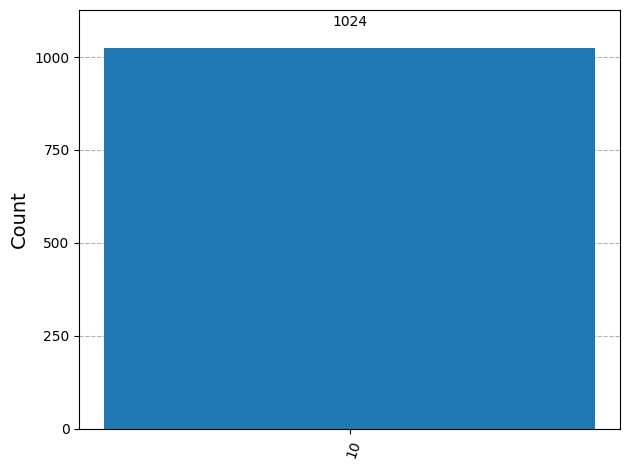

In [24]:
# Create an instance of the AerSimulator
simulator = AerSimulator()

# Run the simulation
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts(qc)

# Plot the results
print("\nCounts:", counts)
plot_histogram(counts)